# 02 — Prévision de la Consommation — version corrigée
**Projet PFE : Système Intelligent de Gestion de l'Eau — Grand Agadir**

### Corrections appliquées
1. **Cible = demande horaire agrégée du réseau** (somme des compteurs, rééchantillonnée à 1 h).
   → la saisonnalité journalière est alors à **24** (correcte), et le MAPE redevient interprétable
   (les totaux horaires sont loin de 0, contrairement aux valeurs 15 min nocturnes ≈ 0).
2. **Comparaison équitable** : les 4 modèles sont évalués en **1-pas-en-avant** sur le même horizon.
3. **Pas de fuite de données** : XGBoost n'utilise **plus** `flowratelpm`/`pressurebar` (mesurés au même
   instant que la cible et inconnus à l'avance) — seulement lags, calendrier et température.

## 0. Imports & Configuration

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt, matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error

DATA_DIR = Path('../data'); MODEL_DIR = Path('../models'); FIG_DIR = Path('../reports/figures')
MODEL_DIR.mkdir(parents=True, exist_ok=True); FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi':110,'figure.figsize':(16,5)})
print('✅ Imports OK')

✅ Imports OK


## 1. Chargement & préparation — demande HORAIRE agrégée

Train 15min : 224,640 | Test 15min : 52,992
Horaire → train 4680 pts, test 1104 pts | moyenne test ≈ 37089 L/h


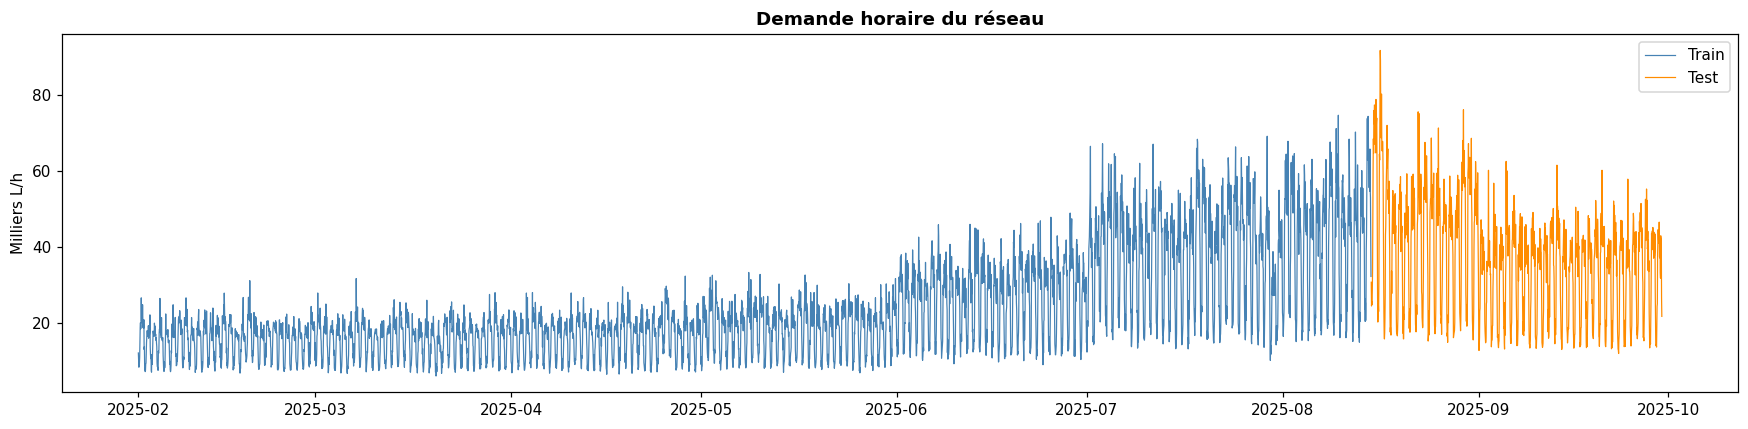

In [2]:
df_train = pd.read_csv(DATA_DIR/'train.csv', parse_dates=['timestamp'])
df_test  = pd.read_csv(DATA_DIR/'test.csv',  parse_dates=['timestamp'])
print(f'Train 15min : {len(df_train):,} | Test 15min : {len(df_test):,}')

def to_hourly(d):
    # cible : somme de TOUS les compteurs par heure (demande réseau)
    y = d.set_index('timestamp')['consumptionliters'].resample('1h').sum()
    # exogènes connus à l'avance : température moyenne + calendrier
    ex = d.set_index('timestamp').resample('1h').agg(temperaturec=('temperaturec','mean'))
    ex['hour']=ex.index.hour; ex['dow']=ex.index.dayofweek; ex['month']=ex.index.month
    ex['is_weekend']=(ex['dow']>=5).astype(int)
    return y, ex.loc[y.index]

y_train, ex_train = to_hourly(df_train)
y_test,  ex_test  = to_hourly(df_test)
print(f'Horaire → train {len(y_train)} pts, test {len(y_test)} pts | moyenne test ≈ {y_test.mean():.0f} L/h')

fig, ax = plt.subplots(figsize=(16,4))
ax.plot(y_train.index, y_train.values/1000, color='steelblue', lw=0.8, label='Train')
ax.plot(y_test.index,  y_test.values/1000,  color='darkorange', lw=0.8, label='Test')
ax.set_title('Demande horaire du réseau', fontweight='bold'); ax.set_ylabel('Milliers L/h'); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR/'fig21_demande_horaire.png', bbox_inches='tight'); plt.show()

In [3]:
SEASONAL = 24  # CORRECT : série horaire → cycle journalier = 24
results = []
def compute_metrics(y_true, y_pred, name):
    y_true=np.asarray(y_true,float); y_pred=np.asarray(y_pred,float); m=y_true>1
    mae=mean_absolute_error(y_true,y_pred); rmse=np.sqrt(mean_squared_error(y_true,y_pred))
    mape=np.mean(np.abs((y_true[m]-y_pred[m])/y_true[m]))*100
    print(f'📊 {name:24s} MAE={mae:8.1f}  RMSE={rmse:8.1f}  MAPE={mape:5.1f}%')
    return {'model':name,'MAE':mae,'RMSE':rmse,'MAPE':mape}
print('✅ Métriques prêtes (MAE, RMSE, MAPE) — toutes sur la même série horaire')

✅ Métriques prêtes (MAE, RMSE, MAPE) — toutes sur la même série horaire


## 2. Modèle 1 — SARIMA (1-pas-en-avant)
Saisonnalité journalière **[24]** (série horaire). Évaluation en 1-pas via `append(..., refit=False)`
→ chaque prédiction utilise les **vraies** valeurs passées (comparaison équitable avec les autres).

⏳ Entraînement SARIMA(2,1,2)(1,1,1)[24] ...
📊 SARIMA[24]               MAE=  3725.4  RMSE=  4914.4  MAPE= 10.7%


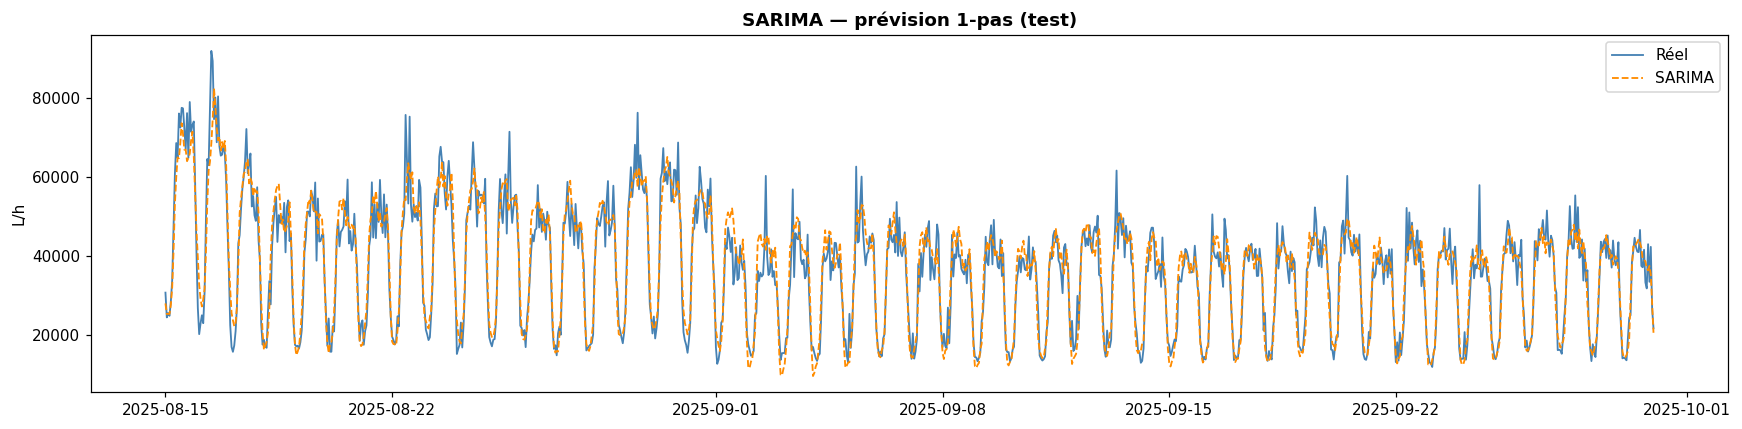

In [4]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
print('⏳ Entraînement SARIMA(2,1,2)(1,1,1)[24] ...')
fit_sarima = SARIMAX(y_train, order=(2,1,2), seasonal_order=(1,1,1,SEASONAL),
                     enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
ext = fit_sarima.append(y_test, refit=False)           # 1-pas-en-avant sur le test
pred_sarima = np.clip(ext.predict(start=y_test.index[0], end=y_test.index[-1]).values, 0, None)
results.append(compute_metrics(y_test.values, pred_sarima, 'SARIMA[24]'))

fig, ax = plt.subplots(figsize=(16,4))
ax.plot(y_test.index, y_test.values, label='Réel', color='steelblue', lw=1.2)
ax.plot(y_test.index, pred_sarima, '--', label='SARIMA', color='darkorange', lw=1.2)
ax.set_title('SARIMA — prévision 1-pas (test)', fontweight='bold'); ax.set_ylabel('L/h'); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR/'fig22_sarima.png', bbox_inches='tight'); plt.show()

## 3. Modèle 2 — Prophet

00:02:11 - cmdstanpy - INFO - Chain [1] start processing
00:02:12 - cmdstanpy - INFO - Chain [1] done processing


📊 Prophet                  MAE= 11020.2  RMSE= 13075.5  MAPE= 33.6%


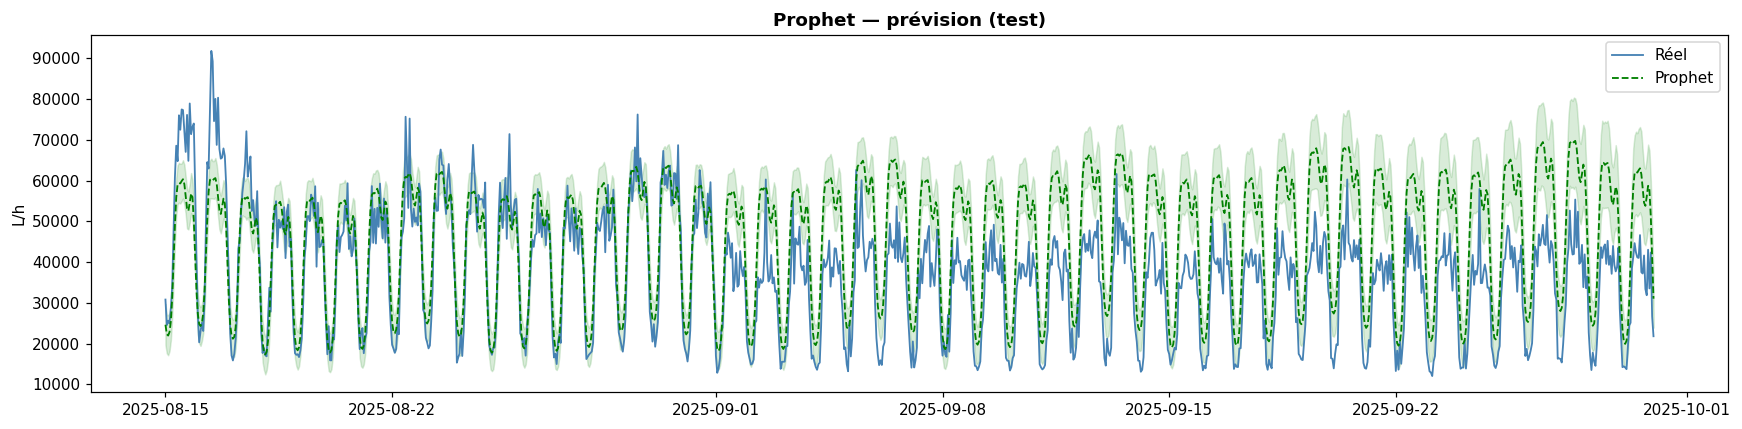

ℹ️  Prophet est un modèle de profil (sans lags) → naturellement désavantagé en 1-pas, c'est attendu.


In [5]:
from prophet import Prophet
m_prophet = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False,
                    seasonality_mode='multiplicative', changepoint_prior_scale=0.05)
m_prophet.fit(pd.DataFrame({'ds':y_train.index, 'y':y_train.values}))
fc = m_prophet.predict(pd.DataFrame({'ds':y_test.index}))
pred_prophet = np.clip(fc['yhat'].values, 0, None)
results.append(compute_metrics(y_test.values, pred_prophet, 'Prophet'))

fig, ax = plt.subplots(figsize=(16,4))
ax.plot(y_test.index, y_test.values, label='Réel', color='steelblue', lw=1.2)
ax.plot(y_test.index, pred_prophet, '--', label='Prophet', color='green', lw=1.2)
ax.fill_between(y_test.index, np.clip(fc['yhat_lower'],0,None), fc['yhat_upper'], alpha=0.15, color='green')
ax.set_title('Prophet — prévision (test)', fontweight='bold'); ax.set_ylabel('L/h'); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR/'fig23_prophet.png', bbox_inches='tight'); plt.show()
print('ℹ️  Prophet est un modèle de profil (sans lags) → naturellement désavantagé en 1-pas, c\'est attendu.')

## 4. Modèle 3 — XGBoost (1-pas, SANS fuite de données)
Features = **lags de la cible** (connus) + **calendrier** + **température**. On **n'utilise pas**
`flowratelpm`/`pressurebar` (inconnus à l'avance et quasi-équivalents à la cible).

📊 XGBoost                  MAE=  3930.2  RMSE=  5188.2  MAPE= 10.9%


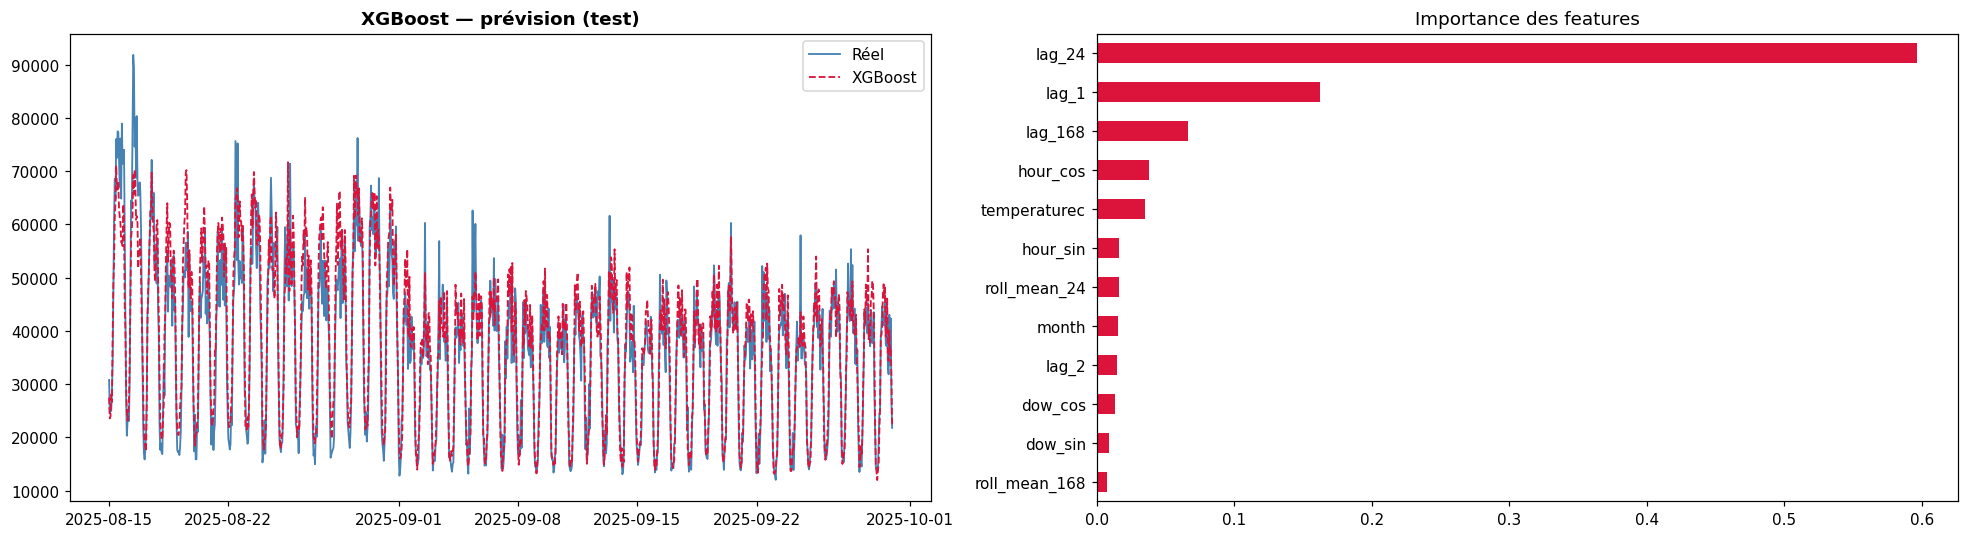

In [6]:
import xgboost as xgb
full = pd.concat([y_train, y_test]); exf = pd.concat([ex_train, ex_test])
X = pd.DataFrame(index=full.index)
for L in [1,2,3,24,168]: X[f'lag_{L}'] = full.shift(L)
X['roll_mean_24']  = full.shift(1).rolling(24).mean()
X['roll_mean_168'] = full.shift(1).rolling(168).mean()
X['hour_sin']=np.sin(2*np.pi*exf['hour']/24); X['hour_cos']=np.cos(2*np.pi*exf['hour']/24)
X['dow_sin']=np.sin(2*np.pi*exf['dow']/7);    X['dow_cos']=np.cos(2*np.pi*exf['dow']/7)
for c in ['temperaturec','month','is_weekend']: X[c]=exf[c]
X['y']=full; X=X.dropna()
Xtr=X[X.index< y_test.index[0]]; Xte=X[X.index>= y_test.index[0]]
FEATURES=[c for c in X.columns if c!='y']

reg = xgb.XGBRegressor(n_estimators=600, max_depth=6, learning_rate=0.05, subsample=0.8,
                       colsample_bytree=0.8, reg_lambda=1.0, random_state=42, n_jobs=-1, verbosity=0)
reg.fit(Xtr[FEATURES], Xtr['y'])
pred_xgb = np.clip(reg.predict(Xte[FEATURES]), 0, None)
results.append(compute_metrics(Xte['y'].values, pred_xgb, 'XGBoost'))

fig, axes = plt.subplots(1,2, figsize=(18,5))
axes[0].plot(Xte.index, Xte['y'].values, label='Réel', color='steelblue', lw=1.2)
axes[0].plot(Xte.index, pred_xgb, '--', label='XGBoost', color='crimson', lw=1.2)
axes[0].set_title('XGBoost — prévision (test)', fontweight='bold'); axes[0].legend()
imp = pd.Series(reg.feature_importances_, index=FEATURES).sort_values()
imp.tail(12).plot(kind='barh', color='crimson', ax=axes[1]); axes[1].set_title('Importance des features')
plt.tight_layout(); plt.savefig(FIG_DIR/'fig24_xgboost.png', bbox_inches='tight'); plt.show()

## 5. Modèle 4 — LSTM (fenêtre 24 h, 1-pas)

📊 LSTM                     MAE=  3985.5  RMSE=  5320.1  MAPE= 11.4%


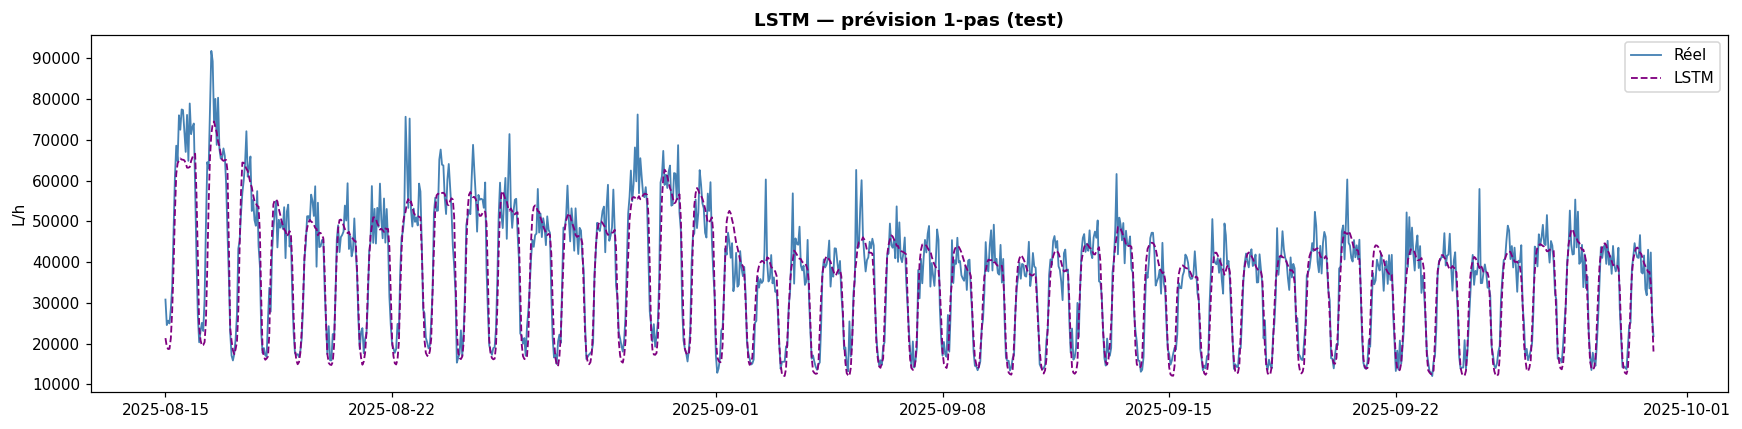

In [7]:
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
tf.random.set_seed(42)

SEQ=24
sc=MinMaxScaler()
a=sc.fit_transform(y_train.values.reshape(-1,1)); b=sc.transform(y_test.values.reshape(-1,1))
def seqs(x):
    X,Y=[],[]
    for i in range(SEQ,len(x)): X.append(x[i-SEQ:i,0]); Y.append(x[i,0])
    return np.array(X).reshape(-1,SEQ,1), np.array(Y)
Xtr_l,ytr_l = seqs(a)
full_sc = np.concatenate([a[-SEQ:], b]); Xte_l,yte_l = seqs(full_sc)

model_lstm = Sequential([LSTM(64, return_sequences=True, input_shape=(SEQ,1)), Dropout(0.2),
                         LSTM(32), Dropout(0.2), Dense(16, activation='relu'), Dense(1)])
model_lstm.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='huber')
es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
hist = model_lstm.fit(Xtr_l, ytr_l, epochs=40, batch_size=64, validation_split=0.15,
                      callbacks=[es], verbose=0)
pred_lstm = np.clip(sc.inverse_transform(model_lstm.predict(Xte_l, verbose=0)).flatten(), 0, None)
y_true_lstm = sc.inverse_transform(yte_l.reshape(-1,1)).flatten()
results.append(compute_metrics(y_true_lstm, pred_lstm, 'LSTM'))

fig, ax = plt.subplots(figsize=(16,4))
ax.plot(y_test.index, y_true_lstm, label='Réel', color='steelblue', lw=1.2)
ax.plot(y_test.index, pred_lstm, '--', label='LSTM', color='purple', lw=1.2)
ax.set_title('LSTM — prévision 1-pas (test)', fontweight='bold'); ax.set_ylabel('L/h'); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR/'fig27_lstm.png', bbox_inches='tight'); plt.show()

## 6. Comparaison équitable des 4 modèles

     COMPARAISON — demande horaire, 1-pas-en-avant
                 MAE      RMSE   MAPE
model                                
SARIMA[24]   3725.41   4914.44  10.66
XGBoost      3930.18   5188.15  10.91
LSTM         3985.48   5320.15  11.44
Prophet     11020.16  13075.46  33.65
🏆 Meilleur modèle (RMSE) : SARIMA[24]


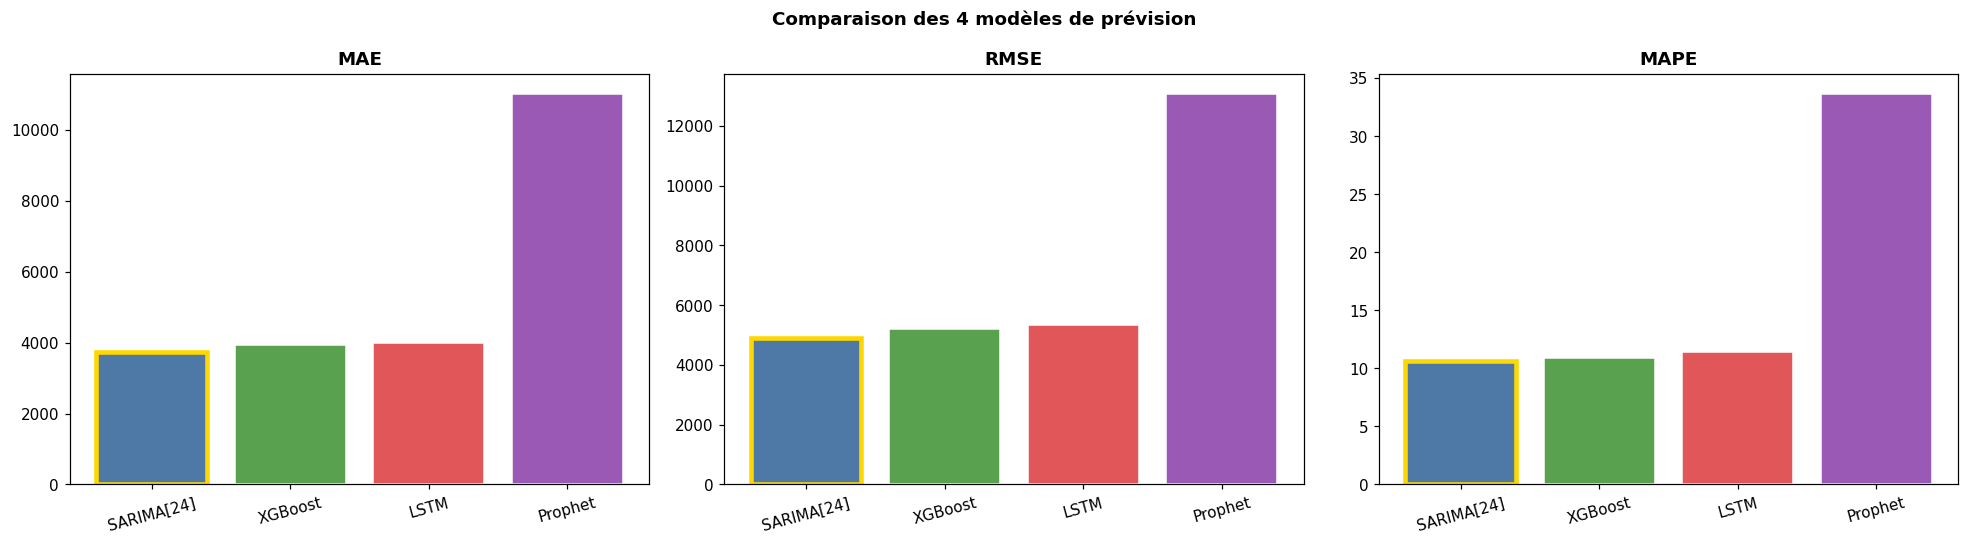

In [8]:
df_res = pd.DataFrame(results).set_index('model').sort_values('RMSE')
print('='*60); print('     COMPARAISON — demande horaire, 1-pas-en-avant'); print('='*60)
print(df_res.round(2).to_string()); print('='*60)
best_model = df_res.index[0]
print(f'🏆 Meilleur modèle (RMSE) : {best_model}')

fig, axes = plt.subplots(1,3, figsize=(18,5))
for ax,metric in zip(axes, ['MAE','RMSE','MAPE']):
    bars=ax.bar(df_res.index, df_res[metric], color=['#4E79A7','#59A14F','#E15759','#9B59B6'][:len(df_res)], edgecolor='white')
    ax.set_title(metric, fontweight='bold'); ax.tick_params(axis='x', rotation=15)
    bars[int(df_res[metric].values.argmin())].set_edgecolor('gold'); bars[int(df_res[metric].values.argmin())].set_linewidth(3)
plt.suptitle('Comparaison des 4 modèles de prévision', fontweight='bold'); plt.tight_layout()
plt.savefig(FIG_DIR/'fig28_comparaison.png', bbox_inches='tight'); plt.show()

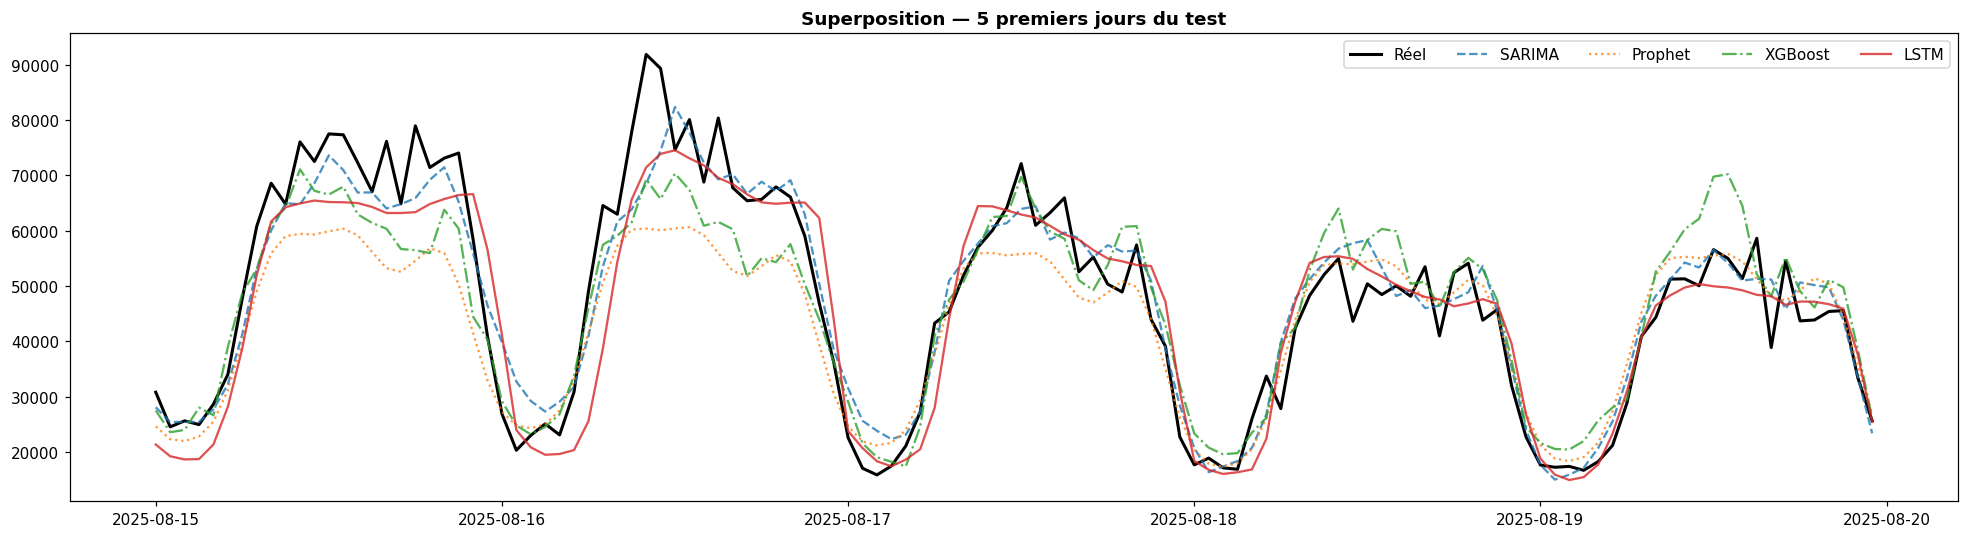

In [9]:
N=24*5
fig, ax = plt.subplots(figsize=(18,5))
ax.plot(y_test.index[:N], y_test.values[:N], label='Réel', color='black', lw=2)
ax.plot(y_test.index[:N], pred_sarima[:N], '--', label='SARIMA', alpha=0.8)
ax.plot(y_test.index[:N], pred_prophet[:N], ':', label='Prophet', alpha=0.8)
ax.plot(y_test.index[:N], pred_xgb[:N], '-.', label='XGBoost', alpha=0.8)
ax.plot(y_test.index[:N], pred_lstm[:N], label='LSTM', alpha=0.8)
ax.set_title('Superposition — 5 premiers jours du test', fontweight='bold'); ax.legend(ncol=5)
plt.tight_layout(); plt.savefig(FIG_DIR/'fig29_superposition.png', bbox_inches='tight'); plt.show()

## 7. Sauvegarde du meilleur modèle

In [10]:
import joblib
joblib.dump(reg, MODEL_DIR/'xgboost_forecaster.pkl')
joblib.dump(m_prophet, MODEL_DIR/'prophet_forecaster.pkl')
model_lstm.save(MODEL_DIR/'lstm_forecaster.keras'); joblib.dump(sc, MODEL_DIR/'lstm_scaler.pkl')
joblib.dump(fit_sarima, MODEL_DIR/'sarima_forecaster.pkl')
joblib.dump(FEATURES, MODEL_DIR/'xgb_features.pkl')
df_res.to_csv(MODEL_DIR/'forecasting_results.csv')

if best_model=='XGBoost':   joblib.dump(reg, MODEL_DIR/'best_forecaster.pkl')
elif best_model=='Prophet': joblib.dump(m_prophet, MODEL_DIR/'best_forecaster.pkl')
elif best_model=='LSTM':    model_lstm.save(MODEL_DIR/'best_forecaster.keras')
else:                       joblib.dump(fit_sarima, MODEL_DIR/'best_forecaster.pkl')
print(f'🏆 Meilleur modèle sauvegardé : {best_model}')
print('🏁 Notebook 02 terminé → 03_anomaly_detection.ipynb')

🏆 Meilleur modèle sauvegardé : SARIMA[24]
🏁 Notebook 02 terminé → 03_anomaly_detection.ipynb
